<a href="https://colab.research.google.com/github/as-arthur/Coding_Camp/blob/main/proyek_analisis_sentimen/Analisis_Sentimen_Fathur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mount Gdrive

In [ ]:
import google.colab as colab
import google.colab.drive
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


# Install Paket

In [41]:
pip install sastrawi googletrans pytube wordcloud tensorflow  google_play_scraper

# Import Modul

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime as dt
import re
import string
import nltk
import csv
import requests
import tensorflow as tf
from google_play_scraper import reviews_all, Sort
from imblearn.over_sampling import RandomOverSampler
from sklearn.utils import class_weight
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GRU, SimpleRNN, LeakyReLU, BatchNormalization, LayerNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
from googletrans import Translator
from io import StringIO
from googleapiclient.discovery import build
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from pytube import YouTube
from googleapiclient.discovery import build
from wordcloud import WordCloud
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load Dataset

In [ ]:
ytb_df = pd.read_csv('/content/drive/MyDrive/Coding Camp DBS Foundation/Proyek/ytb_comments.csv')
ytb_df.head(100)

,Unnamed: 0,review,rating,date,user
0,0,Sudah banyak yg ngeluh ini aplikasi lemot para...,1,2025-04-30 15:18:54,Pengguna Google
1,1,"tidak perlu munculkan popup utk membeli paket,...",1,2025-05-04 01:01:07,Pengguna Google
2,2,"Tolong update yg benar min, cek kuota loading ...",2,2025-05-03 01:20:26,Pengguna Google
3,3,terlalu banyak fitur gak berguna di MyTelkomse...,1,2025-05-01 00:42:26,Pengguna Google
4,4,Harga ELIT jaringan SULIT. KUOTA SERBA MAHAL N...,1,2025-04-24 16:40:24,Pengguna Google
...,...,...,...,...,...
95,95,abis update bukannya makin bagus malah sering ...,1,2025-04-10 17:12:12,Pengguna Google
96,96,Tiap bulan harga paket data naik terus bulan l...,1,2025-04-19 05:14:55,Pengguna Google
97,97,"Niat ngga sih lo bikin aplikasi, bikin emosi a...",1,2025-04-10 03:57:22,Pengguna Google
98,98,coba ask Vero trnyta masih ribet.. masih jauh ...,3,2025-04-11 03:01:09,Pengguna Google


In [ ]:
ytb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  135000 non-null  int64 
 1   review      135000 non-null  object
 2   rating      135000 non-null  int64 
 3   date        135000 non-null  object
 4   user        135000 non-null  object
dtypes: int64(2), object(3)
memory usage: 5.1+ MB


In [ ]:
# Cek baris di mana 'comments' bukan string
print(ytb_df[ytb_df['review'].apply(lambda x: not isinstance(x, str))])

Empty DataFrame
Columns: [Unnamed: 0, review, rating, date, user]
Index: []


# Preprocessing Text

In [ ]:
def cleaningText (text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  text = re.sub(r'#[A-Za-z0-9]+', '', text)
  text = re.sub(r'RT[\s]+', '', text)
  text = re.sub(r'https?:\/\/\S+', '', text)
  text = re.sub(r'[0-9]', '', text)
  text = re.sub(r'[^\w\s]', '', text)

  text = text.replace('\n', ' ')
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = text.strip(' ')
  return text

def casefoldingText (text):
  text = text.lower()
  return text

def tokenizingText (text):
  text = word_tokenize(text)
  return text

def filteringText (text):
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya",
                        "gaa","loh","kah","woi","woii","woy",'yg', 'aja','aj',
                        'tp', 'jg', 'dr', 'pd', 'utk', 'dgn', 'klo', 'kl',"heheheheh",
                        'ini', 'dan', 'itu','ada', 'adalah', 'akan', 'aku',
                        'anda', 'apa', 'atau', 'berapa'
                        ])
  filtered = []
  for txt in text:
      if txt not in listStopwords:
        filtered.append(txt)
  text = filtered
  return text

def stemmingText (text):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  words = text.split()

  stemmed_words = [stemmer.stem(word) for word in words]

  stemmed_text = ' '.join(stemmed_words)

  return stemmed_text

def toSentence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

slangwords = {
    # **1. Slang Umum Indonesia**
    "yg": "yang",
    "aja": "saja",
    "aj": "saja",
    "tp": "tapi",
    "jg": "juga",
    "dr": "dari",
    "pd": "pada",
    "utk": "untuk",
    "dgn": "dengan",
    "klo": "kalau",
    "kl": "kalau",
    "bgt": "banget",
    "maks": "maksimal",
    "masi": "masih",
    "org": "orang",
    "kek": "kayak",
    "kyk": "kayak",
    "bngt": "banget",
    "banget": "sangat",
    "dikit": "sedikit",
    "bkl": "bakal",
    "bbrp": "beberapa",
    "cmn": "cuma",
    "td": "tadi",
    "tll": "terlalu",
    "sm": "sama",
    "keknya": "kayaknya",
    "kayanya": "kayaknya",
    "brp": "berapa",
    "bnyk": "banyak",
    "bener": "benar",
    "bkin": "bikin",
    "bngsd": "bangsat",
    "anj": "anjing",
    "anjir": "anjing",
    "mmk": "vagina",
    "emg": "memang",
    "sbnrnya": "sebenarnya",
    "kmu": "kamu",
    "gw": "aku",
    "gua": "aku",
    "loe": "kamu",
    "lu": "kamu",
    "ama": "sama",
    "gaes": "teman-teman",
    "gpp": "tidak apa-apa",
    "gausah": "tidak usah",
    "gabisa": "tidak bisa",
    "gatau": "tidak tahu",
    "gamau": "tidak mau",
    "gbs": "tidak bisa",
    "gmn": "bagaimana",
    "gtw": "tidak tahu",
    "kzl": "kesal",
    "mager": "malas gerak",
    "mabok": "mabuk",
    "ngegas": "membual",
    "ngakak": "tertawa",
    "nyok": "ayo",
    "pdhl": "padahal",
    "pls": "tolong",
    "sotoy": "sok tahu",
    "tau": "tahu",
    "tbh": "sejujurnya",
    "tmn": "teman",
    "trs": "terus",
    "woles": "santai",
    "wkwk": "tertawa",
    "y": "iya",
    "yoi": "iya",
    "yuk": "ayo",
    "ygy": "ya guys",
    "nggak": "tidak",
    "ganyang": "menghabisi",
    "drpd": "daripada",
    "dah": "sudah",
    "krn": "karena",
    "spy": "supaya",
    "so": "sok",
    "tdk":"tidak",
    "odgj":"orang dalam gangguan jiwa",
    "kalo":"kalau",
    "negri":"negeri",

    # **2. Slang Viral/Media Sosial Indonesia**
    "ahh moment": "momen mengejutkan",
    "begibni": "begini",
    "dimsk": "dimasak",
    "nyapres": "calon presiden",
    "kompteten": "kompeten",
    "ortunya": "orang tuanya",
    "beginianjir": "begini anjir",
    "yutup": "YouTube",
    "yutub": "YouTube",
    "wapres": "wakil presiden",
    "aduhhh": "aduh",
    "pengecutt": "pengecut",
    "dislikenya": "tidak suka nya",
    "didisable": "dinonaktifkan",

    # **3. Slang Global/Gen-Z (TikTok, dll.)**
    "rizz": "karisma",
    "yapping": "cerewet",
    "sigma": "orang mandiri & cool",
    "skibidi": "tidak jelas",
    "fanum tax": "mencuri makanan teman",
    "gyat": "pantat besar",
    "ohio": "aneh/ngaco",
    "grimace shake": "minuman viral McDonald's",
    "L": "loser/kalah",
    "W": "winner/menang",
    "no cap": "jujur",
    "cap": "bohong",
    "based": "keren/berani",
    "sus": "mencurigakan",
    "glazing": "menjilat (figuratif)",
    "pookie": "panggilan sayang",
    "bussin": "enak",
    "slay": "keren",
    "ate": "melakukan dengan baik",
    "periodt": "setuju!",
    "snatched": "terlihat sempurna",
    "bet": "setuju",
    "mid": "biasa saja",
    "smash": "suka/setuju",
    "extra": "berlebihan",
    "delulu": "delusional",
    "touch grass": "keluar dari dunia maya",
    "NPC": "orang membosankan",

    # **4. Singkatan/Internet Lingo**
    "wtb": "want to buy",
    "wts": "want to sell",
    "wtt": "want to trade",
    "smh": "geleng kepala (kesal)",
    "idk": "I don't know",
    "irl": "in real life",
    "fyi": "for your information",
    "tbt": "throwback time",
    "dm": "direct message",
    "pm": "private message",
    "afk": "away from keyboard",
    "btw": "by the way",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "np": "no problem",
    "nvm": "never mind",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "rofl": "rolling on the floor laughing",
    "stfu": "diam!",
    "tf": "what the fuck",
    "thx": "thanks",
    "ty": "thank you",
    "yw": "you're welcome",
    "gg": "good game",
    "gl": "good luck",
    "hf": "have fun",
    "wdym": "what do you mean",
    "fomo": "fear of missing out",
    "dislike":"tidak suka",
    "icymi": "in case you missed it"
}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [ ]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
ytb_df['text_clean'] = ytb_df['review'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
ytb_df['text_casefoldingText'] = ytb_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
ytb_df['text_slangwords'] = ytb_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
ytb_df['text_tokenizingText'] = ytb_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
ytb_df['text_stopword'] = ytb_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
ytb_df['text_akhir'] = ytb_df['text_stopword'].apply(toSentence)

In [ ]:
ytb_df.head(20)

,Unnamed: 0,review,rating,date,user,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,0,Sudah banyak yg ngeluh ini aplikasi lemot para...,1,2025-04-30 15:18:54,Pengguna Google,Sudah banyak yg ngeluh ini aplikasi lemot para...,sudah banyak yg ngeluh ini aplikasi lemot para...,sudah banyak yang ngeluh ini aplikasi lemot pa...,"[sudah, banyak, yang, ngeluh, ini, aplikasi, l...","[ngeluh, aplikasi, lemot, parah, crash, dibene...",ngeluh aplikasi lemot parah crash dibenerin ud...
1,1,"tidak perlu munculkan popup utk membeli paket,...",1,2025-05-04 01:01:07,Pengguna Google,tidak perlu munculkan popup utk membeli paket ...,tidak perlu munculkan popup utk membeli paket ...,tidak perlu munculkan popup untuk membeli pake...,"[tidak, perlu, munculkan, popup, untuk, membel...","[munculkan, popup, membeli, paket, menyebalkan...",munculkan popup membeli paket menyebalkan peng...
2,2,"Tolong update yg benar min, cek kuota loading ...",2,2025-05-03 01:20:26,Pengguna Google,Tolong update yg benar min cek kuota loading l...,tolong update yg benar min cek kuota loading l...,tolong update yang benar min cek kuota loading...,"[tolong, update, yang, benar, min, cek, kuota,...","[tolong, update, min, cek, kuota, loading, cle...",tolong update min cek kuota loading clear cach...
3,3,terlalu banyak fitur gak berguna di MyTelkomse...,1,2025-05-01 00:42:26,Pengguna Google,terlalu banyak fitur gak berguna di MyTelkomse...,terlalu banyak fitur gak berguna di mytelkomse...,terlalu banyak fitur gak berguna di mytelkomse...,"[terlalu, banyak, fitur, gak, berguna, di, myt...","[fitur, berguna, mytelkomsel, aplikasi, berat,...",fitur berguna mytelkomsel aplikasi berat loadi...
4,4,Harga ELIT jaringan SULIT. KUOTA SERBA MAHAL N...,1,2025-04-24 16:40:24,Pengguna Google,Harga ELIT jaringan SULIT KUOTA SERBA MAHAL NG...,harga elit jaringan sulit kuota serba mahal ng...,harga elit jaringan sulit kuota serba mahal ti...,"[harga, elit, jaringan, sulit, kuota, serba, m...","[harga, elit, jaringan, sulit, kuota, serba, m...",harga elit jaringan sulit kuota serba mahal ng...
5,5,setiap updatean terbaru selalu mengalami bug k...,1,2025-04-30 08:50:46,Pengguna Google,setiap updatean terbaru selalu mengalami bug k...,setiap updatean terbaru selalu mengalami bug k...,setiap updatean terbaru selalu mengalami bug k...,"[setiap, updatean, terbaru, selalu, mengalami,...","[updatean, terbaru, mengalami, bug, buka, apli...",updatean terbaru mengalami bug buka aplikasi m...
6,6,"Dari sekian banyak Aplikasi, Cuma MYTelkomsel ...",1,2025-04-23 08:32:47,Pengguna Google,Dari sekian banyak Aplikasi Cuma MYTelkomsel Y...,dari sekian banyak aplikasi cuma mytelkomsel y...,dari sekian banyak aplikasi cuma mytelkomsel y...,"[dari, sekian, banyak, aplikasi, cuma, mytelko...","[sekian, aplikasi, mytelkomsel, berat, kebanya...",sekian aplikasi mytelkomsel berat kebanyakan f...
7,7,apk nya banyak bug! tiap masuk sering buffer. ...,1,2025-05-03 05:30:03,Pengguna Google,apk nya banyak bug tiap masuk sering buffer se...,apk nya banyak bug tiap masuk sering buffer se...,apk nya banyak bug tiap masuk sering buffer se...,"[apk, nya, banyak, bug, tiap, masuk, sering, b...","[apk, bug, masuk, buffer, ditunggu, beratnya, ...",apk bug masuk buffer ditunggu beratnya biasaa ...
8,8,Saya jaringan nya lancar kok kalau mau langgan...,1,2025-04-28 08:42:05,Pengguna Google,Saya jaringan nya lancar kok kalau mau langgan...,saya jaringan nya lancar kok kalau mau langgan...,saya jaringan nya lancar kok kalau mau langgan...,"[saya, jaringan, nya, lancar, kok, kalau, mau,...","[jaringan, lancar, langganan, prime, videodisn...",jaringan lancar langganan prime videodisneynet...
9,9,"aplikasi berat, harga elit paket pelit. jaring...",1,2025-04-30 02:11:24,Pengguna Google,aplikasi berat harga elit paket pelit jaringan...,aplikasi berat harga elit paket pelit jaringan...,aplikasi berat harga elit paket pelit jaringan...,"[aplikasi, berat, harga, elit, paket, pelit, j...","[apl

# Pelabelan

In [ ]:
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter='\t')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    next(reader) #Mengabaikan header kolom

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter='\t')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    next(reader) #Mengabaikan header kolom

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif(score == 0):
        polarity = 'neutral'
        # Jika skor sentimen sama dengan 0, maka polaritas adalah netral
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    # else:
    #     polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [ ]:
results = ytb_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
ytb_df['polarity_score'] = results[0]
ytb_df['polarity'] = results[1]
print(ytb_df['polarity'].value_counts())

polarity
negative    86664
positive    39700
neutral      8636
Name: count, dtype: int64


In [ ]:
ytb_df.head(20)

,Unnamed: 0,review,rating,date,user,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,0,Sudah banyak yg ngeluh ini aplikasi lemot para...,1,2025-04-30 15:18:54,Pengguna Google,Sudah banyak yg ngeluh ini aplikasi lemot para...,sudah banyak yg ngeluh ini aplikasi lemot para...,sudah banyak yang ngeluh ini aplikasi lemot pa...,"[sudah, banyak, yang, ngeluh, ini, aplikasi, l...","[ngeluh, aplikasi, lemot, parah, crash, dibene...",ngeluh aplikasi lemot parah crash dibenerin ud...,-42,negative
1,1,"tidak perlu munculkan popup utk membeli paket,...",1,2025-05-04 01:01:07,Pengguna Google,tidak perlu munculkan popup utk membeli paket ...,tidak perlu munculkan popup utk membeli paket ...,tidak perlu munculkan popup untuk membeli pake...,"[tidak, perlu, munculkan, popup, untuk, membel...","[munculkan, popup, membeli, paket, menyebalkan...",munculkan popup membeli paket menyebalkan peng...,13,positive
2,2,"Tolong update yg benar min, cek kuota loading ...",2,2025-05-03 01:20:26,Pengguna Google,Tolong update yg benar min cek kuota loading l...,tolong update yg benar min cek kuota loading l...,tolong update yang benar min cek kuota loading...,"[tolong, update, yang, benar, min, cek, kuota,...","[tolong, update, min, cek, kuota, loading, cle...",tolong update min cek kuota loading clear cach...,1,positive
3,3,terlalu banyak fitur gak berguna di MyTelkomse...,1,2025-05-01 00:42:26,Pengguna Google,terlalu banyak fitur gak berguna di MyTelkomse...,terlalu banyak fitur gak berguna di mytelkomse...,terlalu banyak fitur gak berguna di mytelkomse...,"[terlalu, banyak, fitur, gak, berguna, di, myt...","[fitur, berguna, mytelkomsel, aplikasi, berat,...",fitur berguna mytelkomsel aplikasi berat loadi...,-9,negative
4,4,Harga ELIT jaringan SULIT. KUOTA SERBA MAHAL N...,1,2025-04-24 16:40:24,Pengguna Google,Harga ELIT jaringan SULIT KUOTA SERBA MAHAL NG...,harga elit jaringan sulit kuota serba mahal ng...,harga elit jaringan sulit kuota serba mahal ti...,"[harga, elit, jaringan, sulit, kuota, serba, m...","[harga, elit, jaringan, sulit, kuota, serba, m...",harga elit jaringan sulit kuota serba mahal ng...,5,positive
5,5,setiap updatean terbaru selalu mengalami bug k...,1,2025-04-30 08:50:46,Pengguna Google,setiap updatean terbaru selalu mengalami bug k...,setiap updatean terbaru selalu mengalami bug k...,setiap updatean terbaru selalu mengalami bug k...,"[setiap, updatean, terbaru, selalu, mengalami,...","[updatean, terbaru, mengalami, bug, buka, apli...",updatean terbaru mengalami bug buka aplikasi m...,-22,negative
6,6,"Dari sekian banyak Aplikasi, Cuma MYTelkomsel ...",1,2025-04-23 08:32:47,Pengguna Google,Dari sekian banyak Aplikasi Cuma MYTelkomsel Y...,dari sekian banyak aplikasi cuma mytelkomsel y...,dari sekian banyak aplikasi cuma mytelkomsel y...,"[dari, sekian, banyak, aplikasi, cuma, mytelko...","[sekian, aplikasi, mytelkomsel, berat, kebanya...",sekian aplikasi mytelkomsel berat kebanyakan f...,18,positive
7,7,apk nya banyak bug! tiap masuk sering buffer. ...,1,2025-05-03 05:30:03,Pengguna Google,apk nya banyak bug tiap masuk sering buffer se...,apk nya banyak bug tiap masuk sering buffer se...,apk nya banyak bug tiap masuk sering buffer se...,"[apk, nya, banyak, bug, tiap, masuk, sering, b...","[apk, bug, masuk, buffer, ditunggu, beratnya, ...",apk bug masuk buffer ditunggu beratnya biasaa ...,-7,negative
8,8,Saya jaringan nya lancar kok kalau mau langgan...,1,2025-04-28 08:42:05,Pengguna Google,Saya jaringan nya lancar kok kalau mau langgan...,saya jaringan nya lancar kok kalau mau langgan...,saya jaringan nya lancar kok kalau mau langgan...,"[saya, jaringan, nya, lancar, kok, kalau, mau,...","[jaringan, lancar, langganan, prime, videodisn...",jaringan lancar langganan prime videodisneynet...,-4,negative
9,9,"aplikasi berat, harga elit paket pelit. jaring...",1,2025-04-30 02:11:24,Pengguna Google,aplikasi berat harga elit paket pelit jaringan...,aplikasi berat harga elit

# Eksplorasi Label

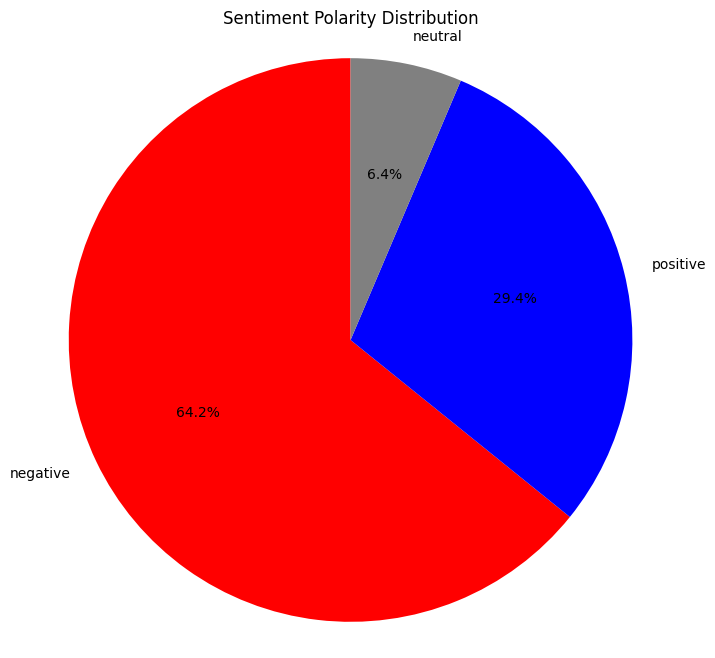

In [ ]:

polarity_counts = ytb_df['polarity'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(polarity_counts, labels=polarity_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'blue', 'grey'])
plt.title('Sentiment Polarity Distribution')
plt.axis('equal')
plt.show()


All Reviews - There are 2077924 words.


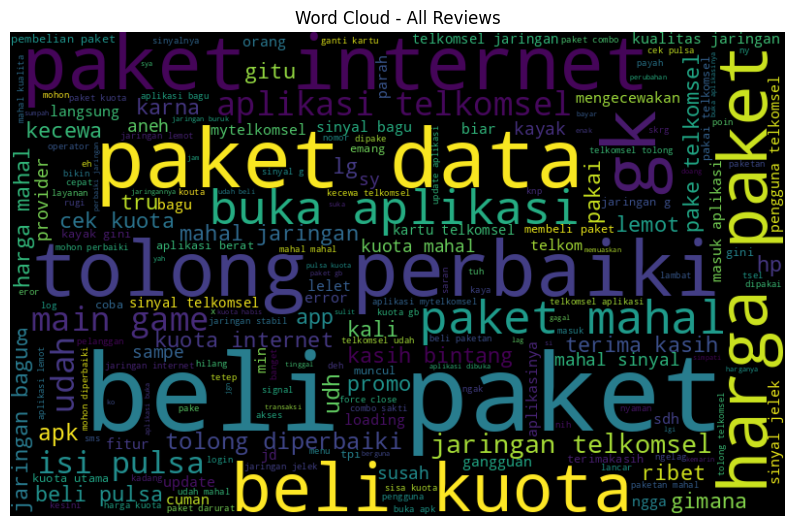

Positive Reviews - There are 622671 words.


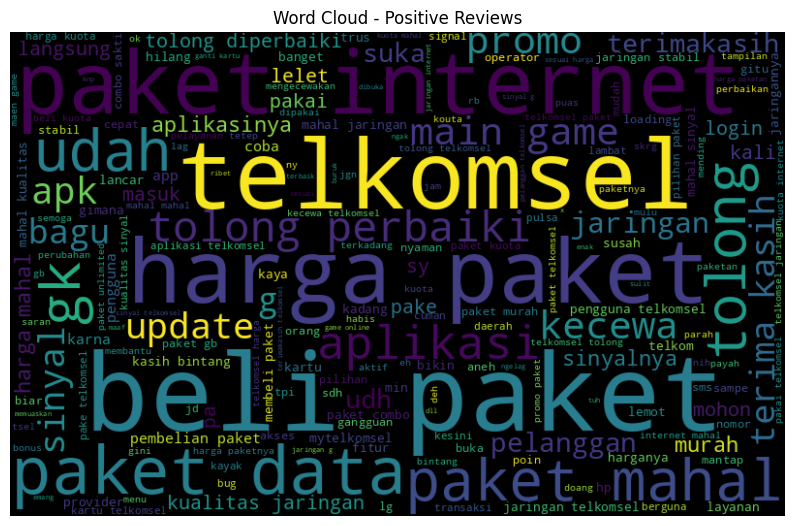

Negative Reviews - There are 1363116 words.


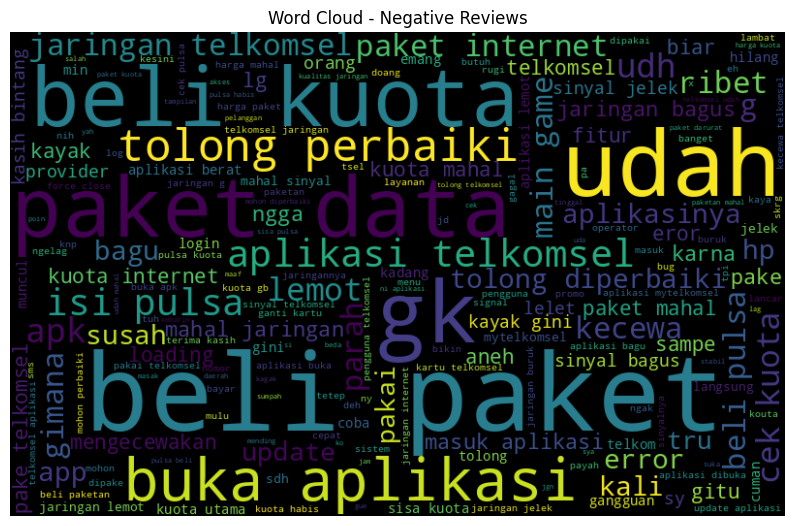

Neutral Reviews - There are 92137 words.


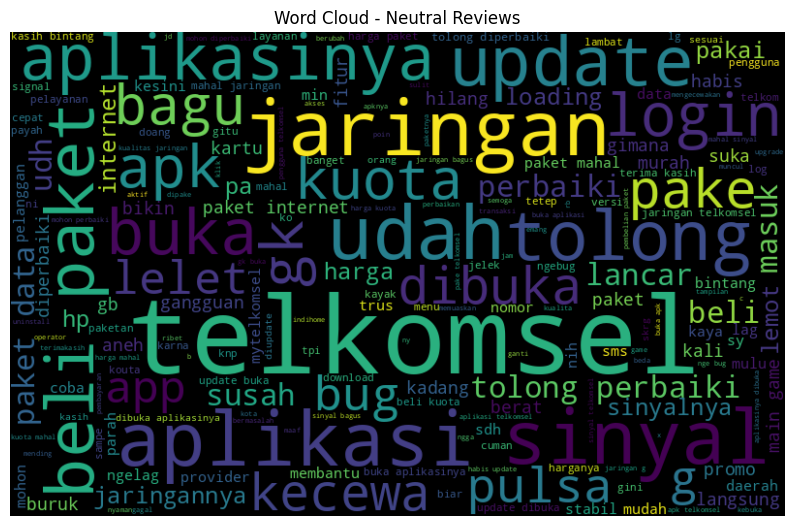

In [ ]:


# Fungsi untuk membuat word cloud
def create_wordcloud(text, title):
    print(f"{title} - There are {len(text.split())} words.")
    wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(text)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud - {title}")
    plt.axis('off')
    plt.show()

# 1. Word Cloud untuk semua review
text_all = " ".join(review for review in ytb_df.text_akhir)
create_wordcloud(text_all, "All Reviews")

# 2. Word Cloud untuk review positif (polarity > 0)
positive_reviews = ytb_df[ytb_df['polarity_score'] > 0]
text_positive = " ".join(review for review in positive_reviews.text_akhir)
create_wordcloud(text_positive, "Positive Reviews")

# 3. Word Cloud untuk review negatif (polarity < 0)
negative_reviews = ytb_df[ytb_df['polarity_score'] < 0]
text_negative = " ".join(review for review in negative_reviews.text_akhir)
create_wordcloud(text_negative, "Negative Reviews")

# 4. Word Cloud untuk review netral (polarity == 0)
neutral_reviews = ytb_df[ytb_df['polarity_score'] == 0]
text_neutral = " ".join(review for review in neutral_reviews.text_akhir)
create_wordcloud(text_neutral, "Neutral Reviews")

# Data Splitting dan Ekstraksi Fitur

In [51]:
X = ytb_df['text_akhir']
y = ytb_df['polarity']

#Ekstraksi dengan TF-IDF
tfidf = TfidfVectorizer (max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
fitur1_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

In [52]:
fitur1_df.head()

,abis,akses,aktif,ampun,aneh,apk,aplikasi,aplikasinya,app,bagus,...,tsel,udah,udh,ulang,unlimited,update,utama,versi,wifi,youtube
0,0.0,0.0,0.0,0.0,0.0,0.0,0.303207,0.0,0.199554,0.0,...,0.0,0.135504,0.0,0.195946,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.126742,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.137610,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.396753,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.235988,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0


In [ ]:
# fitur2_df.head()

In [53]:
fitur1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Columns: 200 entries, abis to youtube
dtypes: float64(200)
memory usage: 206.0 MB


In [ ]:
# fitur2_df.info()

In [54]:
#Bagi data menjadi data latih dan uji
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42) # Membagi menjadi 80/20 untuk Deep Learning
X_train2, X_test2, y_train2, y_test2 = train_test_split(fitur1_df, y, test_size=0.2, random_state=42) #Membagi menjadi 80/20 untuk TF-IDF

# Modeling

##Model 1 (LSTM )

### Pelatihan Model 1

In [55]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train1)

X_train1 = tokenizer.texts_to_sequences(X_train1)
X_test1 = tokenizer.texts_to_sequences(X_test1)

# Pad sequences to ensure uniform length
max_length = max(len(seq) for seq in X_train1)  # Get the maximum sequence length
X_train1 = pad_sequences(X_train1, maxlen=max_length, padding='post')
X_test1 = pad_sequences(X_test1, maxlen=max_length, padding='post')

over_sampler = RandomOverSampler()
X_train1, y_train1 = over_sampler.fit_resample(X_train1, y_train1)
print(X_train1.shape, y_train1.shape)

(207834, 151) (207834,)


In [ ]:
model1 = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=128,
        input_length=max_length,
        input_shape=(max_length,),
        mask_zero=True
    ),
    Bidirectional(LSTM(
        units=16,
        activation='tanh',
        recurrent_dropout=0.3,
        return_sequences=False,
    )),
    Dropout(0.5),
    BatchNormalization(momentum=0.99),
    LayerNormalization(),
    LeakyReLU(alpha=0.1),
    Dense(
        units=3,
        activation='softmax',
        kernel_regularizer=regularizers.l2(0.01)
    )
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 151, 128)       │    10,889,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,907,939 (41.61 MB)

 Trainable params: 10,907,875 (41.61 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
from sklearn.utils import class_weight
label_encoder = LabelEncoder()
y_train1 = label_encoder.fit_transform(y_train1)
y_test1 = label_encoder.transform(y_test1)

class_weight = class_weight.compute_class_weight('balanced', classes=np.unique(y_train1), y=y_train1)
class_weight_dict = dict(enumerate(class_weight))

# Continue with your model training
train1 = model1.fit(
    X_train1,
    y_train1,
    class_weight=class_weight_dict,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)



Epoch 1/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1302s 497ms/step - accuracy: 0.7452 - loss: 0.6340 - val_accuracy: 0.8943 - val_loss: 0.3169
Epoch 2/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1304s 502ms/step - accuracy: 0.9296 - loss: 0.2296 - val_accuracy: 0.9215 - val_loss: 0.2362
Epoch 3/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1325s 496ms/step - accuracy: 0.9596 - loss: 0.1431 - val_accuracy: 0.9674 - val_loss: 0.1079
Epoch 4/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1356s 501ms/step - accuracy: 0.9748 - loss: 0.0966 - val_accuracy: 0.9670 - val_loss: 0.1078
Epoch 5/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1270s 489ms/step - accuracy: 0.9831 - loss: 0.0687 - val_accuracy: 0.9826 - val_loss: 0.0612
Epoch 6/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1301s 501ms/step - accuracy: 0.9869 - loss: 0.0551 - val_accuracy: 0.9917 - val_loss: 0.0353
Epoch 7/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1314s 490ms/step - accuracy: 0.9891 - loss: 0.0467 - val_accuracy: 0.9895 - val_loss: 0.0391
Epoch 8/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1250s 477ms/s

### Evaluasi Model 1

In [ ]:
evaluasi1 = model1.evaluate(X_test1, y_test1)
print(f'Test Loss: {evaluasi1[0]}')
print(f'Test Accuracy: {evaluasi1[1]}')

# Get predicted labels
y_pred1 = model1.predict(X_test1)
y_pred1 = np.argmax(y_pred1, axis=1)  # Convert probabilities to class labels

# Generate confusion matrix using predicted labels (y_pred1)
cm = confusion_matrix(y_test1, y_pred1)
print(cm)
print(classification_report(y_test1, y_pred1))


844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9295 - loss: 0.3767
Test Loss: 0.37303683161735535
Test Accuracy: 0.9299259185791016
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 51ms/step
[[16628   496   262]
 [  291  1051   395]
 [  154   294  7429]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     17386
           1       0.57      0.61      0.59      1737
           2       0.92      0.94      0.93      7877

    accuracy                           0.93     27000
   macro avg       0.82      0.83      0.83     27000
weighted avg       0.93      0.93      0.93     27000



## Model 2 (GRU )

In [ ]:
model2 = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=256,
        input_length=max_length,
        input_shape=(max_length,),
        mask_zero=True
    ),
    Bidirectional(GRU(
        units=16,
        activation='tanh',
        recurrent_dropout=0.3
    )),
    Dropout(0.5),
    BatchNormalization(momentum=0.99),
    LayerNormalization(),
    LeakyReLU(alpha=0.1),
    Dense(
        units=16,
        activation='relu'
    ),
    Dense(
        units=3,
        activation='softmax'
    )
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 151, 256)       │    21,778,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        26,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,805,251 (83.18 MB)

 Trainable params: 21,805,187 (83.18 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
model2.fit(
    X_train1,
    y_train1,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1758s 673ms/step - accuracy: 0.7086 - loss: 0.6484 - val_accuracy: 0.9092 - val_loss: 0.2591
Epoch 2/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1787s 683ms/step - accuracy: 0.9212 - loss: 0.2182 - val_accuracy: 0.9208 - val_loss: 0.2083
Epoch 3/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1824s 684ms/step - accuracy: 0.9509 - loss: 0.1386 - val_accuracy: 0.9382 - val_loss: 0.1549
Epoch 4/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1813s 680ms/step - accuracy: 0.9644 - loss: 0.1035 - val_accuracy: 0.9624 - val_loss: 0.0913
Epoch 5/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1819s 679ms/step - accuracy: 0.9705 - loss: 0.0854 - val_accuracy: 0.9544 - val_loss: 0.1137
Epoch 6/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1831s 682ms/step - accuracy: 0.9734 - loss: 0.0776 - val_accuracy: 0.9696 - val_loss: 0.0675
Epoch 7/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1821s 682ms/step - accuracy: 0.9763 - loss: 0.0686 - val_accuracy: 0.9685 - val_loss: 0.0715
Epoch 8/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 1824s 683ms/s

In [ ]:
evaluasi2 = model2.evaluate(X_test1, y_test1)
print(f'Test Loss: {evaluasi2[0]}')
print(f'Test Accuracy: {evaluasi2[1]}')

cm2 = confusion_matrix(y_test1, evaluasi2)
print(cm2)
print(classification_report(y_test1, evaluasi2))

844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.8907 - loss: 0.4022
Test Loss: 0.3990630507469177
Test Accuracy: 0.8905925750732422
[[16628   496   262]
 [  291  1051   395]
 [  154   294  7429]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     17386
           1       0.57      0.61      0.59      1737
           2       0.92      0.94      0.93      7877

    accuracy                           0.93     27000
   macro avg       0.82      0.83      0.83     27000
weighted avg       0.93      0.93      0.93     27000



## Model 3 (Random Forest)

In [37]:
model3 = RandomForestClassifier(
    class_weight='balanced',  # Menangani kelas tidak seimbang
    random_state=42,
    n_jobs=-1  # Gunakan semua core CPU
)

# Parameter grid untuk tuning Random Forest
param_grid = {
    'n_estimators': [500],  # Jumlah pohon
    'max_depth': [None],  # Kedalaman maksimum pohon
    'min_samples_split': [5],   # Minimum sampel untuk split
    'min_samples_leaf': [1],     # Minimum sampel di leaf
    'max_features': ['sqrt']   # Jumlah fitur untuk split terbaik
}

# Gunakan GridSearchCV
grid_search = RandomizedSearchCV(
    estimator=model3,
    param_distributions=param_grid,
    cv=5,
    verbose=1,
    n_jobs=-1  # Paralelisasi untuk GridSearch
)

# Latih model
grid_search.fit(X_train2, y_train2)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1],
                                        'min_samples_split': [5],
                                        'n_estimators': [500]},
                   verbose=1)

In [38]:
y_pred3 = grid_search.predict(X_test2)
print('accuraccy', accuracy_score(y_test2, y_pred3))
print(classification_report(y_test2, y_pred3))

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

cm3 = confusion_matrix(y_test2, y_pred3)
print(cm3)

accuraccy 0.812037037037037
              precision    recall  f1-score   support

    negative       0.86      0.89      0.88     17386
     neutral       0.50      0.37      0.42      1737
    positive       0.75      0.73      0.74      7877

    accuracy                           0.81     27000
   macro avg       0.70      0.66      0.68     27000
weighted avg       0.80      0.81      0.81     27000

Best parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best score: 0.8117314814814816
[[15536   368  1482]
 [  682   638   417]
 [ 1858   268  5751]]


In [61]:
model_3= Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=128,
        input_length=max_length,
        input_shape=(max_length,),
        mask_zero=True
    ),
     Bidirectional(SimpleRNN(
        units=16,
        activation='tanh',
        recurrent_dropout=0.3,
        return_sequences=False,
    )),
    Dropout(0.5),
    BatchNormalization(momentum=0.99),
    LayerNormalization(),
    LeakyReLU(alpha=0.1),
    Dense(
        units=3,
        activation='softmax',
        kernel_regularizer=regularizers.l2(0.01)
    )
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

model_3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 151, 128)       │    10,889,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,894,019 (41.56 MB)

 Trainable params: 10,893,955 (41.56 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
from sklearn.utils import class_weight
label_encoder = LabelEncoder()
y_train1 = label_encoder.fit_transform(y_train1)
y_test1 = label_encoder.transform(y_test1)

class_weight = class_weight.compute_class_weight('balanced', classes=np.unique(y_train1), y=y_train1)
class_weight_dict = dict(enumerate(class_weight))

model_3.fit(
    X_train1,
    y_train1,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/20
 328/2598 ━━━━━━━━━━━━━━━━━━━━ 11:37 307ms/step - accuracy: 0.4282 - loss: 1.1848

In [ ]:
y_pred3 = model_3.predict(X_test2)
print('accuraccy', accuracy_score(y_test2, y_pred3))
print(classification_report(y_test2, y_pred3))